In [1]:
import numpy as np
import pandas as pd
from StochasticSimulationsNew.ReactionNetworkLanguage import make_parser
from StochasticSimulationsNew.MultiGPUsupport import SSA, spread_parameter_sets_among_gpus
from RL4CRN.utils.stochastic_visualizations import plot_simulation_summary
from RL4CRN.utils.stochastic import quick_measurement_SSA
from RL4CRN.utils.stochastic_visualizations import plot_simulation_summary

import math
import time  
import random

import logging 

logging.basicConfig(level=logging.INFO)

start_time = time.time()

parser, lexer = make_parser()

f = open('/local0/rossin/git/stochasticApproaches/Test/GE_std.rn')
text = ''.join(f.readlines())
crn = parser.parse(text)

# Gene Expression
# sample parameters within ranges
n_parameter_sets = 1
parameters = [
    [
        2,#random.random()+1,
        2,#random.random()+1,
        1,#random.random()+1,
        1 #random.random()+1
    ] for i in range(n_parameter_sets) ]

# BDP
# n_parameter_sets = 1000
# parameters = [
#     [
#         random.random()*10,
#         random.random()*10
#     ] for i in range(n_parameter_sets) ]

parameter_sets = spread_parameter_sets_among_gpus(parameters)

# ssa
output = SSA(crn, parameter_sets, t_fin=10, n_trajectories=10000, max_threads=1000, t_step=0.1, t_control_step=-1)

# import os
# os.makedirs('scratch_output', exist_ok=True)
# output.to_csv('scratch_output/GE_100pfix_100t.csv', index=False)

# print(output)

end_time = time.time()

import warnings
warnings.filterwarnings("ignore", module="ipykernel.iostream")

logging.debug(f"ELAPSED TIME: {end_time-start_time}")

INFO:root:GPU 0 finished in 0.1464710235595703 seconds


In [2]:
# Group by time and calculate mean and std for species P and M
summary = output.groupby('time')[['P', 'M']].agg(['mean', 'std'])

# Display the first few rows
print(summary)

           P                 M          
        mean       std    mean       std
time                                    
0.0   0.0000  0.000000  0.0000  0.000000
0.1   0.0033  0.059072  0.0997  0.323683
0.2   0.0152  0.129501  0.1877  0.477170
0.3   0.0281  0.180315  0.2712  0.580934
0.4   0.0452  0.231867  0.3458  0.672360
...      ...       ...     ...       ...
9.6   0.6848  1.183634  1.4045  1.614416
9.7   0.6826  1.183468  1.4024  1.622818
9.8   0.6749  1.176668  1.3993  1.628903
9.9   0.6777  1.189607  1.3978  1.632367
10.0  0.6727  1.175293  1.3927  1.633816

[101 rows x 4 columns]


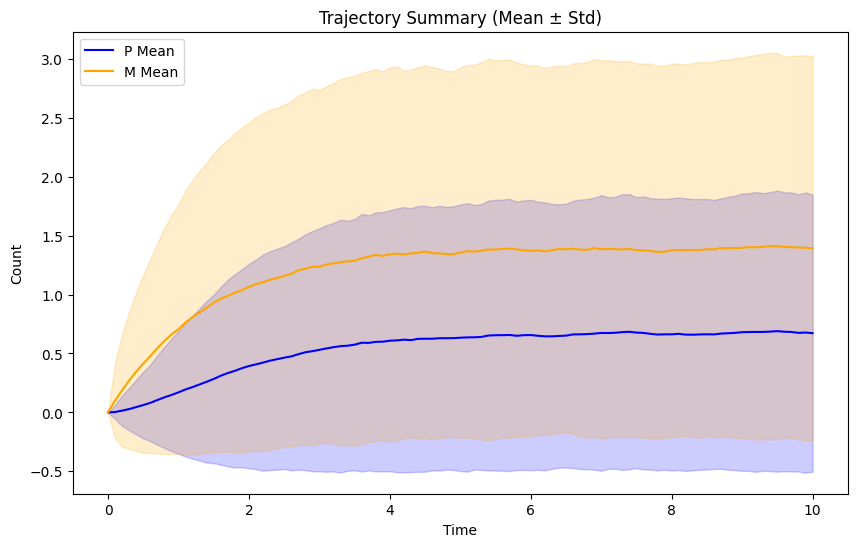

In [3]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

# Plot P
p_mean = summary[('P', 'mean')]
p_std = summary[('P', 'std')]
plt.plot(summary.index, p_mean, label='P Mean', color='blue')
plt.fill_between(summary.index, p_mean - p_std, p_mean + p_std, color='blue', alpha=0.2)

# Plot M
m_mean = summary[('M', 'mean')]
m_std = summary[('M', 'std')]
plt.plot(summary.index, m_mean, label='M Mean', color='orange')
plt.fill_between(summary.index, m_mean - m_std, m_mean + m_std, color='orange', alpha=0.2)

plt.xlabel('Time')
plt.ylabel('Count')
plt.title('Trajectory Summary (Mean ± Std)')
plt.legend()
plt.show()

In [4]:
crn_text = """
// --- Inputs (External Signals) ---
input u_1;
input u_2;
input u_3;

// --- Species Definition ---
species OUT, X_1, X_2, X_3 = 0;

// --- Reactions ---

// 1. Generation from inputs (0-order)
emptyset -- u_1 -> X_1:1;
emptyset -- u_2 -> X_2:1;
emptyset -- u_3 -> X_3:1;

// 2. Catalytic production of X_3 by X_1
// X_1 ----> X_1 + X_3
X_1:1 -- mak(0.05915942043066025) -> X_1:1, X_3:1;

// 3. Conversion of X_3 to OUT
// X_3 ----> OUT
X_3:1 -- mak(0.33624395728111267) -> OUT:1;

// 4. Conversion of OUT to X_2
// OUT ----> X_2
OUT:1 -- mak(1.0009981393814087) -> X_2:1;

// 5. Annihilation of X_1 and X_2
// X_1 + X_2 ----> ∅
X_1:1, X_2:1 -- mak(2.170705556869507) -> emptyset;

// 6. Catalytic production of OUT by X_3 (requires 2 X_3 to proceed)
// X_3 + X_3 ----> OUT + X_3
X_3:2 -- mak(0.9167826771736145) -> OUT:1, X_3:1;
"""

parser, lexer = make_parser()
crn = parser.parse(crn_text)

import itertools 
# all combinations of 0,1 for three inputs
base = [0,1]
parameters = list(itertools.product(base, repeat=3))

parameter_sets = spread_parameter_sets_among_gpus(parameters)
output = SSA(crn, parameter_sets, t_fin=1000, n_trajectories=100, max_threads=10000, t_step=0.1, t_control_step=-1)


output


INFO:root:GPU 0 finished in 0.6319520473480225 seconds


,X_3,X_2,X_1,OUT,time,parameter_index,gpu,u_3,u_2,u_1
0,0,0,0,0,0.0,0,0,0,0,0
1,0,0,0,0,0.1,0,0,0,0,0
2,0,0,0,0,0.2,0,0,0,0,0
3,0,0,0,0,0.3,0,0,0,0,0
4,0,0,0,0,0.4,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...
8000795,65538,15,4,65523,999.6,7,0,1,1,1
8000796,65538,15,4,65523,999.7,7,0,1,1,1
8000797,65538,15,4,65523,999.8,7,0,1,1,1
8000798,65538,15,4,65523,999.9,7,0,1,1,1


INFO:root:GPU 0 finished in 0.7216641902923584 seconds


Plotting mode: Raw (Aggregating now)


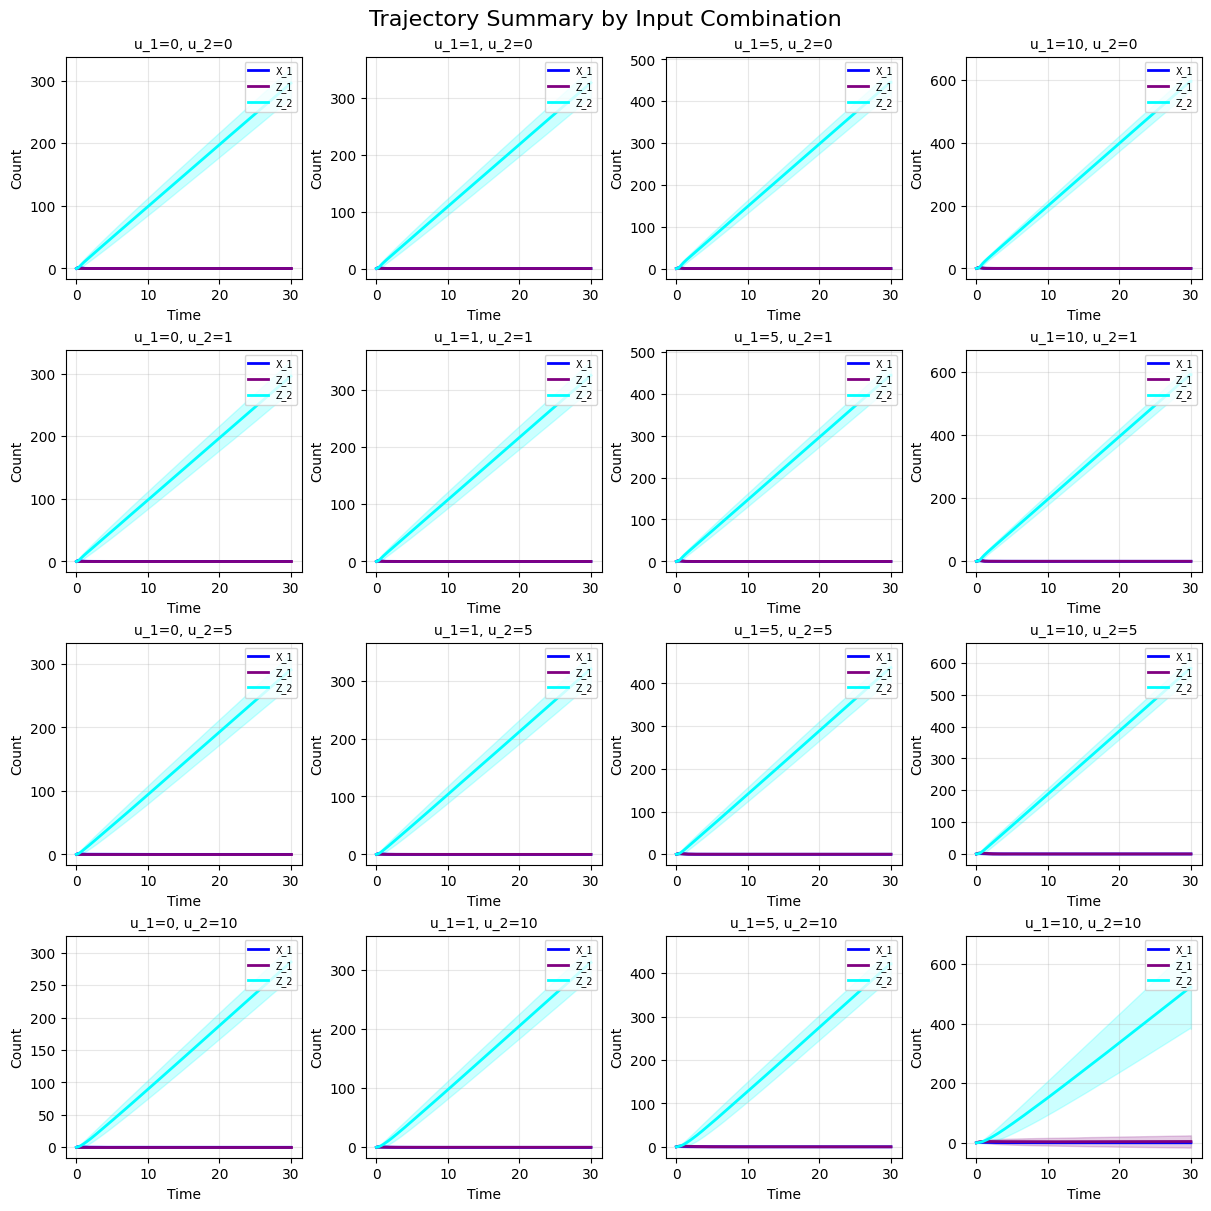

In [5]:
crn_text = """
// --- Inputs (External Signals) ---
input u_1;
input u_2;

// --- Species Definition ---
species X_1, Z_1, Z_2 = 0;

// --- Reactions ---

// 1. Generation of Z_1 driven by u_1
// ∅ ----> Z_1
emptyset -- u_1 -> Z_1:1;

// 2. Degradation of X_1 driven by u_2
// X_1 ----> ∅
X_1:1 -- mak(u_2) -> emptyset;

// 3. Spontaneous production of X_1
// ∅ ----> X_1 + X_1
emptyset -- mak(4.94618034362793) -> X_1:2;

// 4. Conversion of X_1 to Z_2
// X_1 ----> Z_2
X_1:1 -- mak(4.515851020812988) -> Z_2:1;

// 5. Catalytic degradation of X_1 by Z_2
// X_1 + Z_2 ----> Z_2  (X_1 consumed, Z_2 preserved)
X_1:1, Z_2:1 -- mak(6.90656852722168) -> Z_2:1;

// 6. Catalytic degradation of Z_2 by Z_1
// Z_1 + Z_2 ----> Z_1  (Z_2 consumed, Z_1 preserved)
// Z_1:1, Z_2:1 -- mak(24.235246658325195) -> Z_1:1;

// 7. Interaction of Z_1 and Z_2 producing X_1
// Z_1 + Z_2 ----> X_1 + X_1
Z_1:1, Z_2:1 -- mak(6.87056827545166) -> X_1:2;
"""

# Parse the new CRN
parser, lexer = make_parser()
crn = parser.parse(crn_text)

import itertools 
import numpy as np

# Create combinations of 0, 0.5, 1.0, 1.5 for the two inputs
base = [0, 1, 5, 10]
# We have 2 inputs: u_1, u_2
parameters = list(itertools.product(base, repeat=2))

# Distribute to GPU
parameter_sets = spread_parameter_sets_among_gpus(parameters)

# Run Simulation
output = SSA(crn, parameter_sets, t_fin=30, n_trajectories=10000, max_threads=10000, t_step=0.1, t_control_step=-1)

# Visualize Results for the Output Species X_1
# You can add 'Z_1' and 'Z_2' to the list if you want to see the hidden species
plot_simulation_summary(output, species_cols=["X_1", "Z_1", "Z_2"])

In [6]:
crn.species["Z_1"].value

0

In [ ]:
import pandas as pd
from RL4CRN.utils.stochastic import quick_measurement_SSA

# Example Usage
summary_output, has_diverged = quick_measurement_SSA(
    crn, 
    parameters, 
    t_fin=30, 
    n_trajectories=1000, 
    species_to_measure=['X_1']
)

summary_output

INFO:root:GPU 0 finished in 0.19697356224060059 seconds


time parameter_index u_2 u_1    X_1          
                                     mean       std
0      0.0               0   0   0  0.000  0.000000
1      0.0               1   0   1  0.000  0.000000
2      0.0               2   0   5  0.000  0.000000
3      0.0               3   0  10  0.000  0.000000
4      0.0               4   1   0  0.000  0.000000
...    ...             ...  ..  ..    ...       ...
4811  30.0              11   5  10  0.009  0.130138
4812  30.0              12  10   0  0.004  0.089398
4813  30.0              13  10   1  0.009  0.130138
4814  30.0              14  10   5  0.013  0.151175
4815  30.0              15  10  10  0.141  0.750788

[4816 rows x 6 columns]

Plotting mode: Summarized (Pre-calculated)


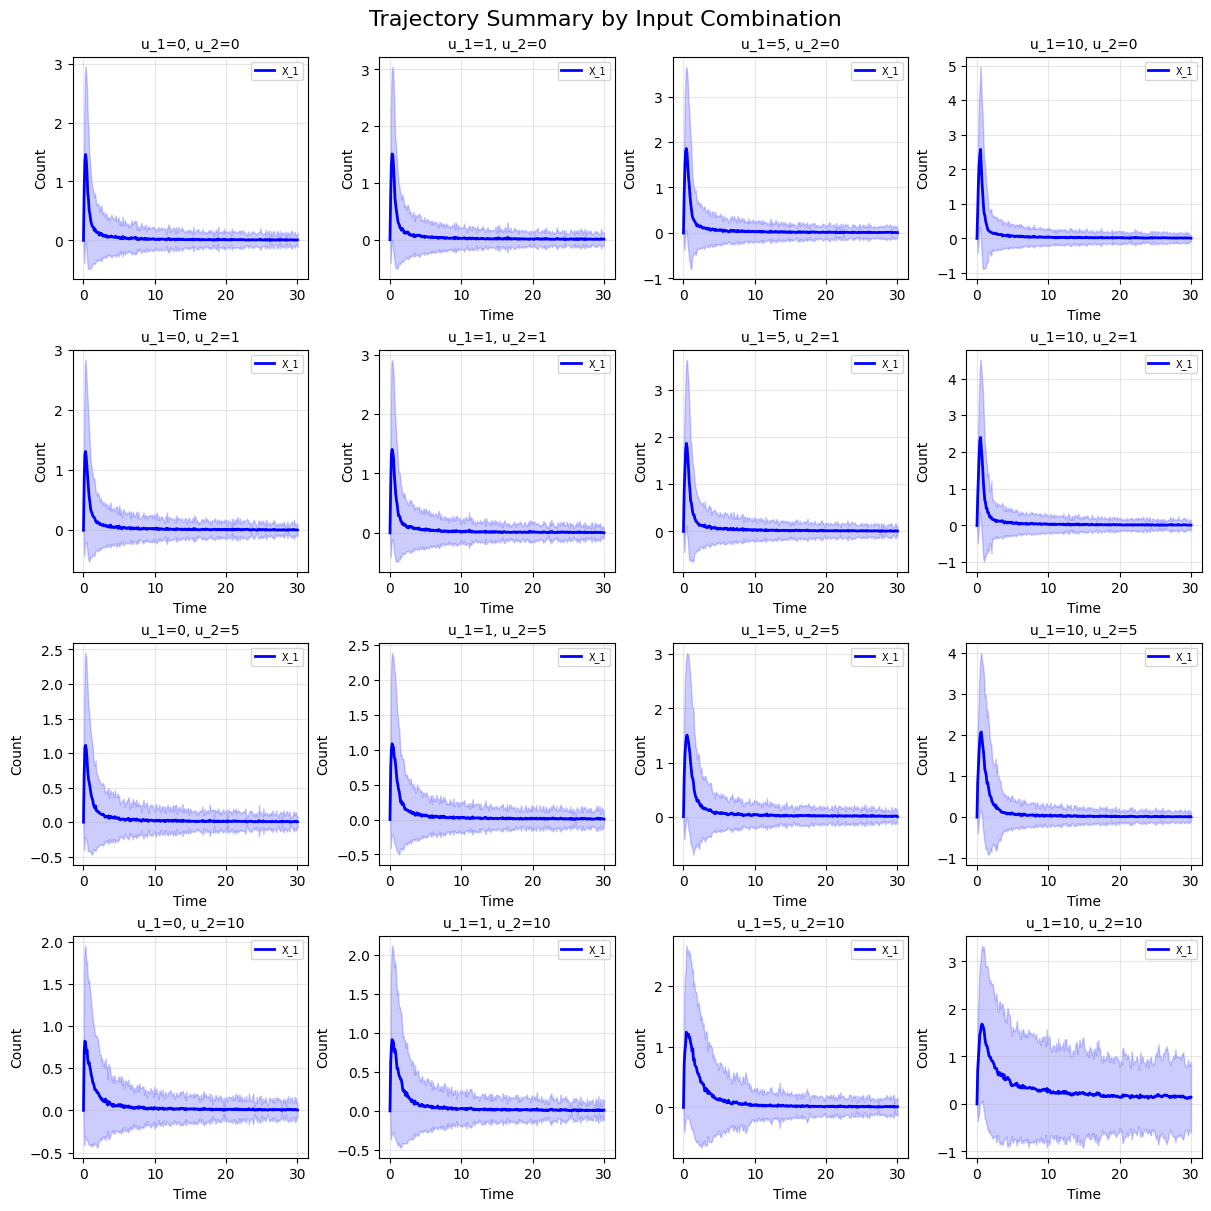

In [8]:
plot_simulation_summary(summary_output, species_cols=["X_1"])

In [9]:
%reload_ext autoreload
%autoreload 2

# Import general packages
from openpyxl import Workbook, load_workbook
from openpyxl.utils import get_column_letter
from datetime import datetime
import torch
from matplotlib import pyplot as plt
from pytorch_lightning.loggers import CometLogger
import numpy as np
from itertools import product
from tqdm import tqdm

# Import Agent-Environment packages
from RL4CRN.environments.environment import Environment
from RL4CRN.environments.parallel_environments import ParallelEnvironments
from RL4CRN.environments.serial_environments import SerialEnvironments
from RL4CRN.agents.reinforce_agent import REINFORCEAgent
from RL4CRN.policies.add_reaction_by_ordered_index import AddReactionByOrderedIndex
from RL4CRN.policies.add_reaction_by_index import AddReactionByIndex

# Import Interface packages
from RL4CRN.env2agent_interface.explicit_observer import ExplicitObserver
from RL4CRN.env2agent_interface.explicit_tensorizer import ExplicitTensorizer
from RL4CRN.agent2env_interface.library_actuator import LibraryActuator
from RL4CRN.agent2env_interface.iocrn_stepper import IOCRNStepper

# Import CRN packages
from RL4CRN.iocrns.iocrn import IOCRN
from RL4CRN.iocrns.reactions import MassAction
from RL4CRN.utils.ic import IC
from RL4CRN.iocrns.reaction_library import construct_mass_action_library

# Import Reward packages
from RL4CRN.rewards.deterministic import dynamic_tracking_error

In [10]:
# Construct the template CRN
# add dilution and production reactions for all species
productions = []
dilutions = []
n_inputs = 3
species_labels = [f'X_{i+1}' for i in range(n_inputs)] 
for i,s in enumerate(species_labels):
    productions.append(MassAction(reactant_labels=[], product_labels=[s], input_channels=[f'u_{i+1}'], params=[1.], params_controllability=[True]))
    dilutions.append(MassAction(reactant_labels=[s], product_labels=[], input_channels=["u_1"], params=[2.], params_controllability=[True])) 

# add x1 to out
productions.append(MassAction(reactant_labels=['X_1'], product_labels=['OUT'], input_channels=[None], params=[1.0], params_controllability=[True]))
# add diluting output
species_labels.append('OUT') # add output species label
# dilutions.append(MassAction(reactant_labels=['OUT'], product_labels=[], input_channels=[None], params=[1.0], params_controllability=[True]))
# productions.append(MassAction(reactant_labels=[], product_labels=['OUT'], input_channels=[None], params=[.5], params_controllability=[True]))

# support_nodes = ['S1', 'S2']
# species_labels.extend(support_nodes) # add support nodes to species labels

crn_template = IOCRN(productions + dilutions, output_labels=['OUT'])
crn_template.compile()
p = crn_template.num_inputs # Number of inputs of the IOCRNs
print("Template CRN:")
print(crn_template)

# Construct the library of possible reactions
library = construct_mass_action_library(species_labels=species_labels, order=2)
crn_template.set_library_context(library)
M = len(library.reactions) # Number of possible reactions
K = library.get_num_parameters() # Total number of parameters in all the reactions of the library
print("Library of possible reactions:")
print(library)
print("------------------------------------------------")

Template CRN:
Inputs: ['u_1', 'u_2', 'u_3'] 
Species: ['OUT', 'X_1', 'X_2', 'X_3'] 
Output Species: ['OUT'] 
∅ ----> X_1;  [MAK(1.0, u_1)]
∅ ----> X_2;  [MAK(1.0, u_2)]
∅ ----> X_3;  [MAK(1.0, u_3)]
X_1 ----> OUT;  [MAK(1.0)]
X_1 ----> ∅;  [MAK(2.0, u_1)]
X_2 ----> ∅;  [MAK(2.0, u_1)]
X_3 ----> ∅;  [MAK(2.0, u_1)]
Library of possible reactions:
Number of reactions: 211
R0: ∅ ----> ∅;  [MAK(None)]
R1: ∅ ----> X_1;  [MAK(None)]
R2: ∅ ----> X_2;  [MAK(None)]
R3: ∅ ----> X_3;  [MAK(None)]
R4: ∅ ----> OUT;  [MAK(None)]
R5: ∅ ----> X_1 + X_1;  [MAK(None)]
R6: ∅ ----> X_1 + X_2;  [MAK(None)]
R7: ∅ ----> X_1 + X_3;  [MAK(None)]
R8: ∅ ----> OUT + X_1;  [MAK(None)]
R9: ∅ ----> X_2 + X_2;  [MAK(None)]
R10: ∅ ----> X_2 + X_3;  [MAK(None)]
R11: ∅ ----> OUT + X_2;  [MAK(None)]
R12: ∅ ----> X_3 + X_3;  [MAK(None)]
R13: ∅ ----> OUT + X_3;  [MAK(None)]
R14: ∅ ----> OUT + OUT;  [MAK(None)]
R15: X_1 ----> ∅;  [MAK(None)]
R16: X_1 ----> X_2;  [MAK(None)]
R17: X_1 ----> X_3;  [MAK(None)]
R18: X_1 ----> OUT

⏱️  [DSL Generation      ] completed in 0.0000 seconds
⏱️  [Parsing & Lexing    ] completed in 0.0094 seconds
⏱️  [Parameter Setup     ] completed in 0.0000 seconds


INFO:root:GPU 0 finished in 0.24228310585021973 seconds


⏱️  [SSA Simulation      ] completed in 0.9022 seconds
Plotting mode: Summarized (Pre-calculated)
⏱️  [Visualization       ] completed in 0.0499 seconds


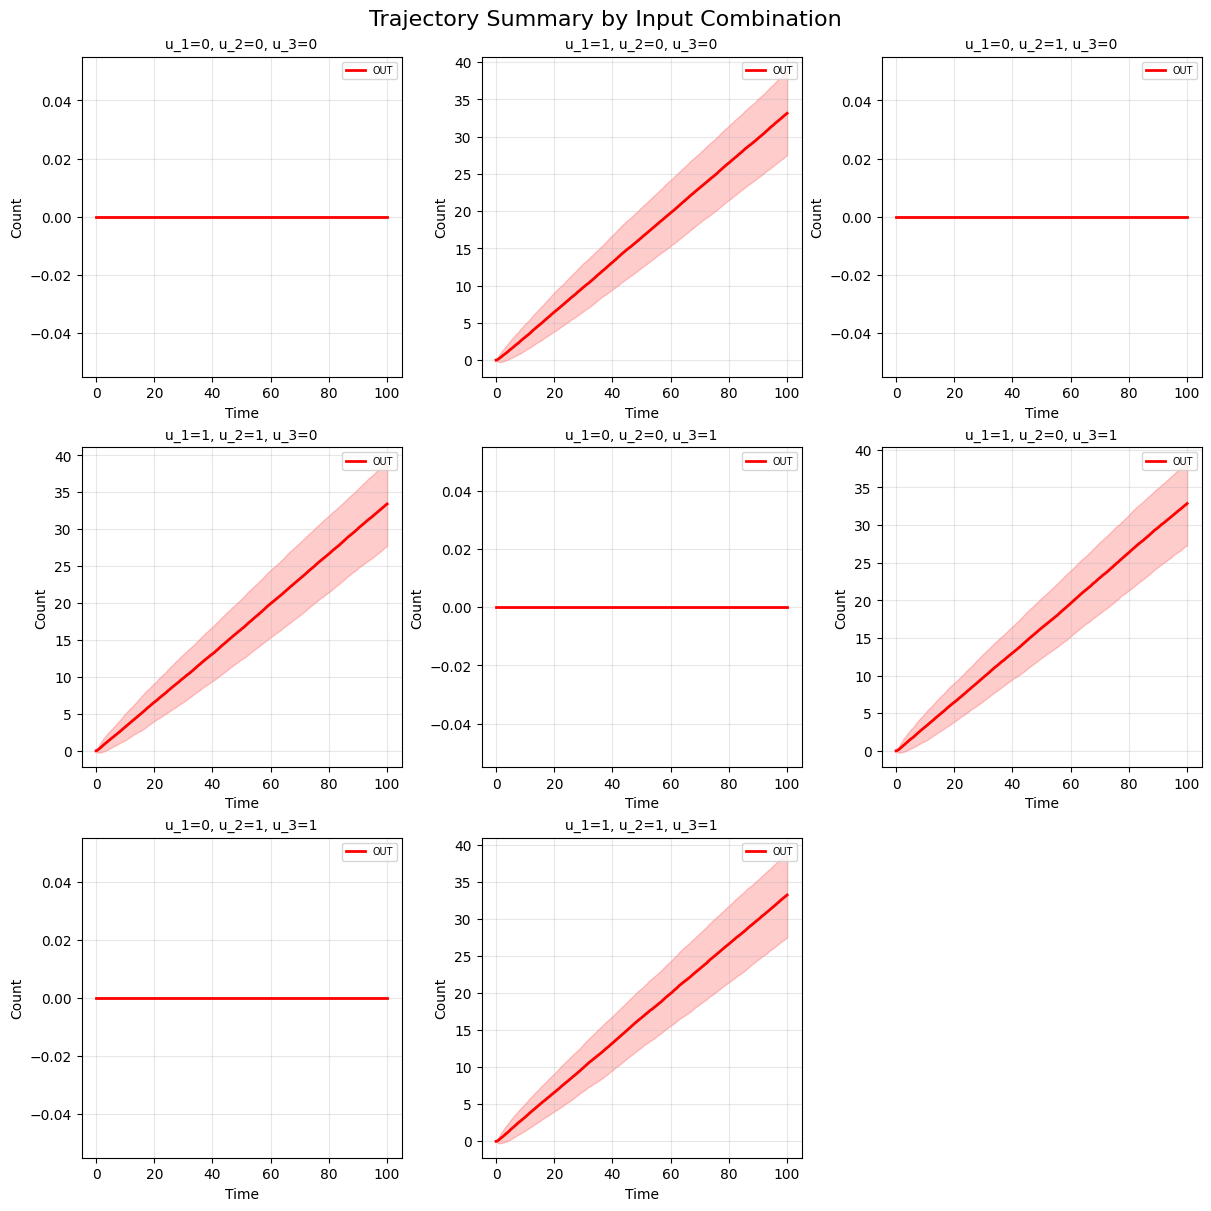

In [ ]:
import time
import itertools

# --- 1. Define a Simple Timer Class ---
class Benchmark:
    def __init__(self, name):
        self.name = name
    
    def __enter__(self):
        self.start_time = time.perf_counter()
        return self
    
    def __exit__(self, exc_type, exc_val, exc_tb):
        self.end_time = time.perf_counter()
        elapsed = self.end_time - self.start_time
        print(f"⏱️  [{self.name:<20}] completed in {elapsed:.4f} seconds")

# --- 2. Your Benchmarked Code ---

# Segment A: DSL Generation (IOCRN -> String)
with Benchmark("DSL Generation"):
    crn_text = crn_template.to_reaction_file()

# Segment B: Parsing (String -> Parser Object)
with Benchmark("Parsing & Lexing"):
    parser, lexer = make_parser()
    crn = parser.parse(crn_text)

# Segment C: Setup
with Benchmark("Parameter Setup"):
    # [0,1] 3 times -> 8 combinations
    parameters = list(itertools.product([0,1], repeat=3))

# Segment D: The Heavy Lifting (Simulation)
with Benchmark("SSA Simulation"):
    measurements, has_diverged = quick_measurement_SSA(
        crn, 
        parameters, 
        t_fin=100, 
        n_trajectories=1000, 
        species_to_measure=['OUT']
    )

# Segment E: Plotting
with Benchmark("Visualization"):
    plot_simulation_summary(measurements, species_cols=["OUT"])

INFO:root:GPU 0 finished in 8.230565547943115 seconds


Plotting mode: Raw (Aggregating now)


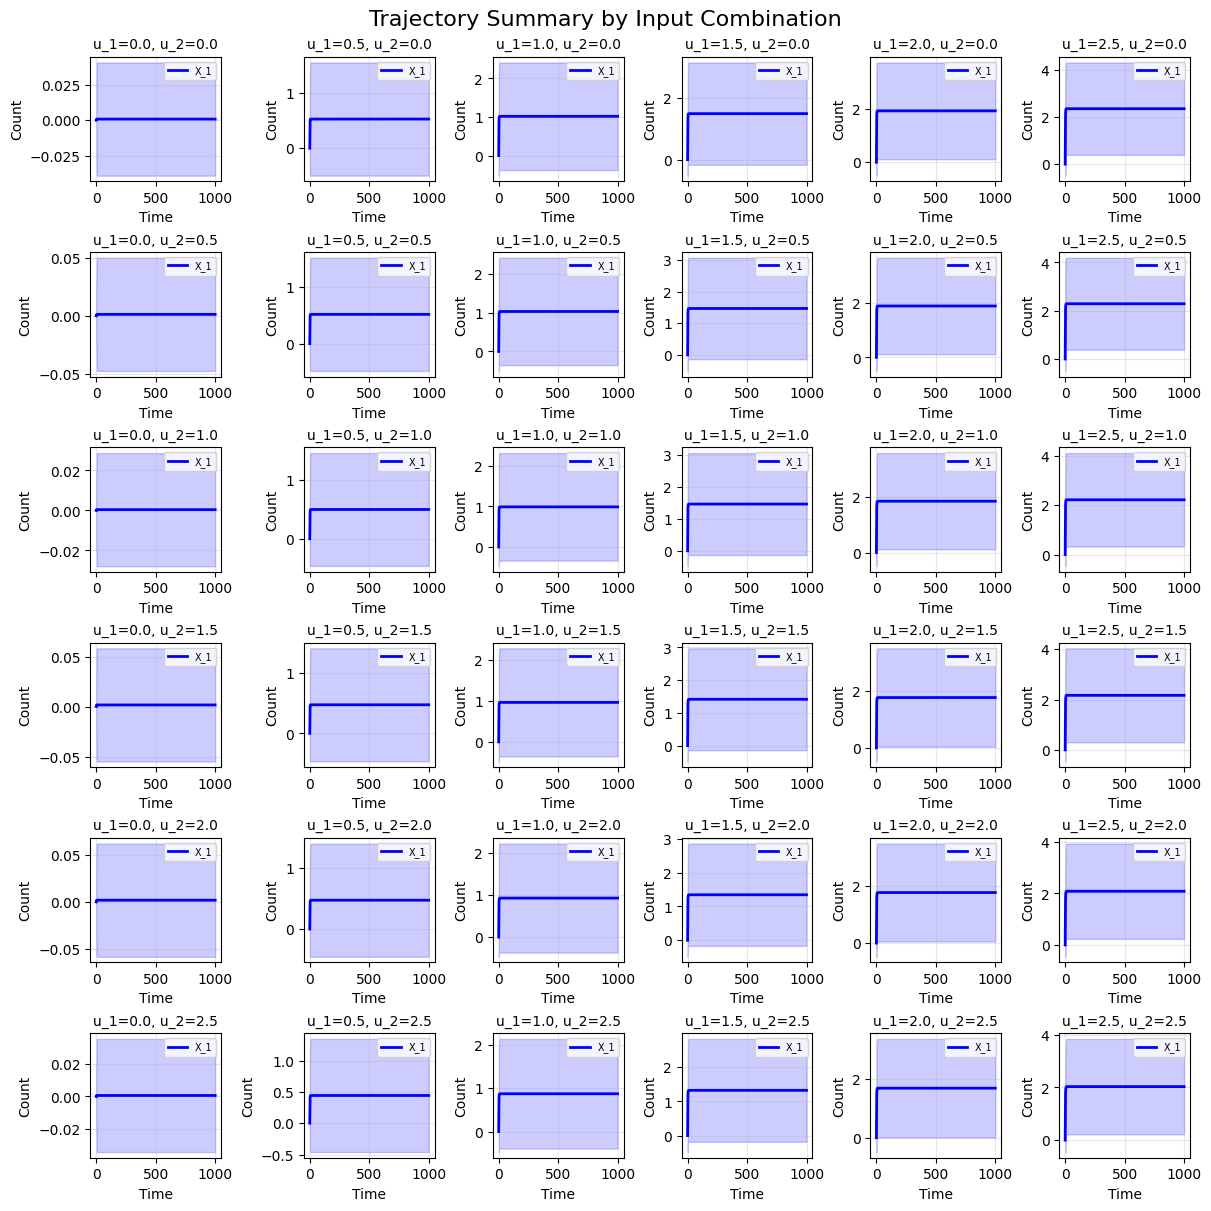

In [12]:
import itertools 
import numpy as np
# Assuming specific library imports exist in your environment context:
# from your_library import make_parser, spread_parameter_sets_among_gpus, SSA, plot_simulation_summary

crn_text = """
// --- Inputs (External Signals) ---
input u_1;
input u_2;

// --- Species Definition ---
species X_1, Z_1, Z_2 = 0;

// --- Reactions ---

// 1. Generation of Z_1 driven by u_1
// ∅ ----> Z_1;  [MAK(1.0, u_1)]
emptyset -- u_1 -> Z_1:1;

// 2. Production of Z_2 dimer from nothing (Constitutive)
// ∅ ----> Z_2 + Z_2;  [MAK(1.2321200370788574)]
emptyset -- mak(1.2321200370788574) -> Z_2:2;

// 3. Degradation of X_1 driven by u_2
// X_1 ----> ∅;  [MAK(1.0, u_2)]
X_1:1 -- mak(u_2) -> emptyset;

// 4. Annihilation of X_1 dimer
// X_1 + X_1 ----> ∅;  [MAK(1.6283903121948242)]
X_1:2 -- mak(1.6283903121948242) -> emptyset;

// 5. Conversion of X_1 dimer to Z_2 dimer
// X_1 + X_1 ----> Z_2 + Z_2;  [MAK(2.040458917617798)]
X_1:2 -- mak(2.040458917617798) -> Z_2:2;

// 6. Interaction of Z_1 and Z_2 producing X_1 dimer
// Z_1 + Z_2 ----> X_1 + X_1;  [MAK(1.8805781602859497)]
Z_1:1, Z_2:1 -- mak(1.8805781602859497) -> X_1:2;

// 7. Condensation/Loss of Z_2 dimer
// Z_2 + Z_2 ----> Z_2;  [MAK(2.362504243850708)]
Z_2:2 -- mak(2.362504243850708) -> Z_2:1;
"""

# Parse the new CRN
parser, lexer = make_parser()
crn = parser.parse(crn_text)

# Create combinations of input levels
base = [0, 0.5, 1.0, 1.5, 2., 2.5]
# We have 2 inputs: u_1, u_2
parameters = list(itertools.product(base, repeat=2))

# Distribute to GPU
parameter_sets = spread_parameter_sets_among_gpus(parameters)

# Run Simulation
# Using the optimized settings you requested
output = SSA(
    crn, 
    parameter_sets, 
    t_fin=1000, 
    n_trajectories=10000, 
    max_threads=10000, 
    t_step=1., 
    t_control_step=-1, 
    max_value=100000
)

# Visualize Results for X_1
plot_simulation_summary(output, species_cols=["X_1"])